# Mood Space Interpolation Demo

This notebook demonstrates how to:
1. Train a Mood Space compression model on a small set of placeholder images
2. Generate interpolations across all of the images using the trained model
3. Visualize the interpolation results produced by blended cluster correspondences

The demo uses simple color swatches so you can quickly replace them with your own assets.

In [1]:
# Import required libraries
import torch
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

from app import train_mood_space, perform_two_image_interpolation, perform_n_image_interpolation

## Prepare Images

Input Images (side by side):


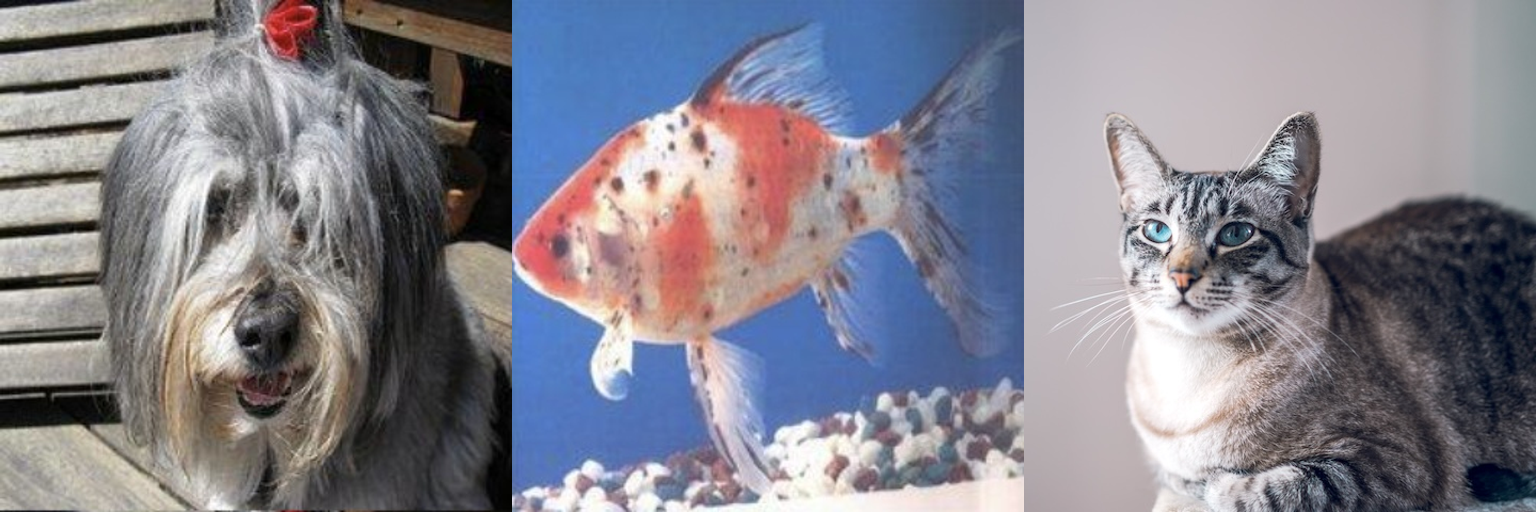

In [2]:
# Load images
image_paths = [
    "images/dog1.jpg",
    "images/fish.jpg",
    "images/cat.jpg"
]

image_size = (512, 512)
image_list = [Image.open(path).convert("RGB").resize(image_size) for path in image_paths]

print("Input Images (side by side):")
cols = len(image_list)
width, height = image_list[0].size
grid = Image.new("RGB", (cols * width, height))
for i, img in enumerate(image_list):
    grid.paste(img, (i * width, 0))
display(grid)

## Train Mood Space Model

In [3]:
# Train the Mood Space compression model
print("Training Mood Space model...")
model, trainer = train_mood_space(
    pil_images=image_list, 
    learning_rate=0.001, 
    training_steps=1000,
    mlp_width=512,
    mlp_layers=2
)
""
print("Training completed!")

Training Mood Space model...


Using cache found in /home/andrew/.cache/torch/hub/facebookresearch_dino_main


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


Training: |          | 0/? [00:00<?, ?it/s]

Training completed!


## Generate Interpolations

Blend the inputs according to predefined weight vectors. Each vector is a linear combination over the three source images.

In [4]:
# Corner weight controls how much each vertex is emphasized
corner_weight = 1.0

# Define interpolation weights for three-way blending
weight_schedule = [
    np.array([corner_weight, 0.0, 0.0], dtype=np.float32),
    np.array([0.0, corner_weight, 0.0], dtype=np.float32),
    np.array([0.0, 0.0, corner_weight], dtype=np.float32),
]

# Barycentric grid between the corners
grid_steps = 4  # increase for finer grid
for i in range(grid_steps + 1):
    for j in range(grid_steps + 1 - i):
        k = grid_steps - i - j
        # skip pure corners already added
        if (i == grid_steps and j == 0 and k == 0) or (i == 0 and j == grid_steps and k == 0) or (i == 0 and j == 0 and k == grid_steps):
            continue
        w = np.array([i, j, k], dtype=np.float32) * corner_weight / grid_steps
        weight_schedule.append(w)

print(f"Total interpolation weights: {len(weight_schedule)}")

print("Generating interpolated images...")
interpolated_images = perform_n_image_interpolation(
    image_list=image_list, 
    base_image_idx=0,
    model=model, 
    interpolation_weights=weight_schedule,
    n_clusters=20, 
    match_method='hungarian',
    use_dino_matching=True
)

print(f"Generated {len(interpolated_images)} interpolated images")

Total interpolation weights: 15
Generating interpolated images...


Using cache found in /home/andrew/.cache/torch/hub/facebookresearch_dino_main


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

...

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

Generated 15 interpolated images


## Triangle Visualization

Place each interpolated image within a barycentric triangle whose corners correspond to the three corner weight configurations.

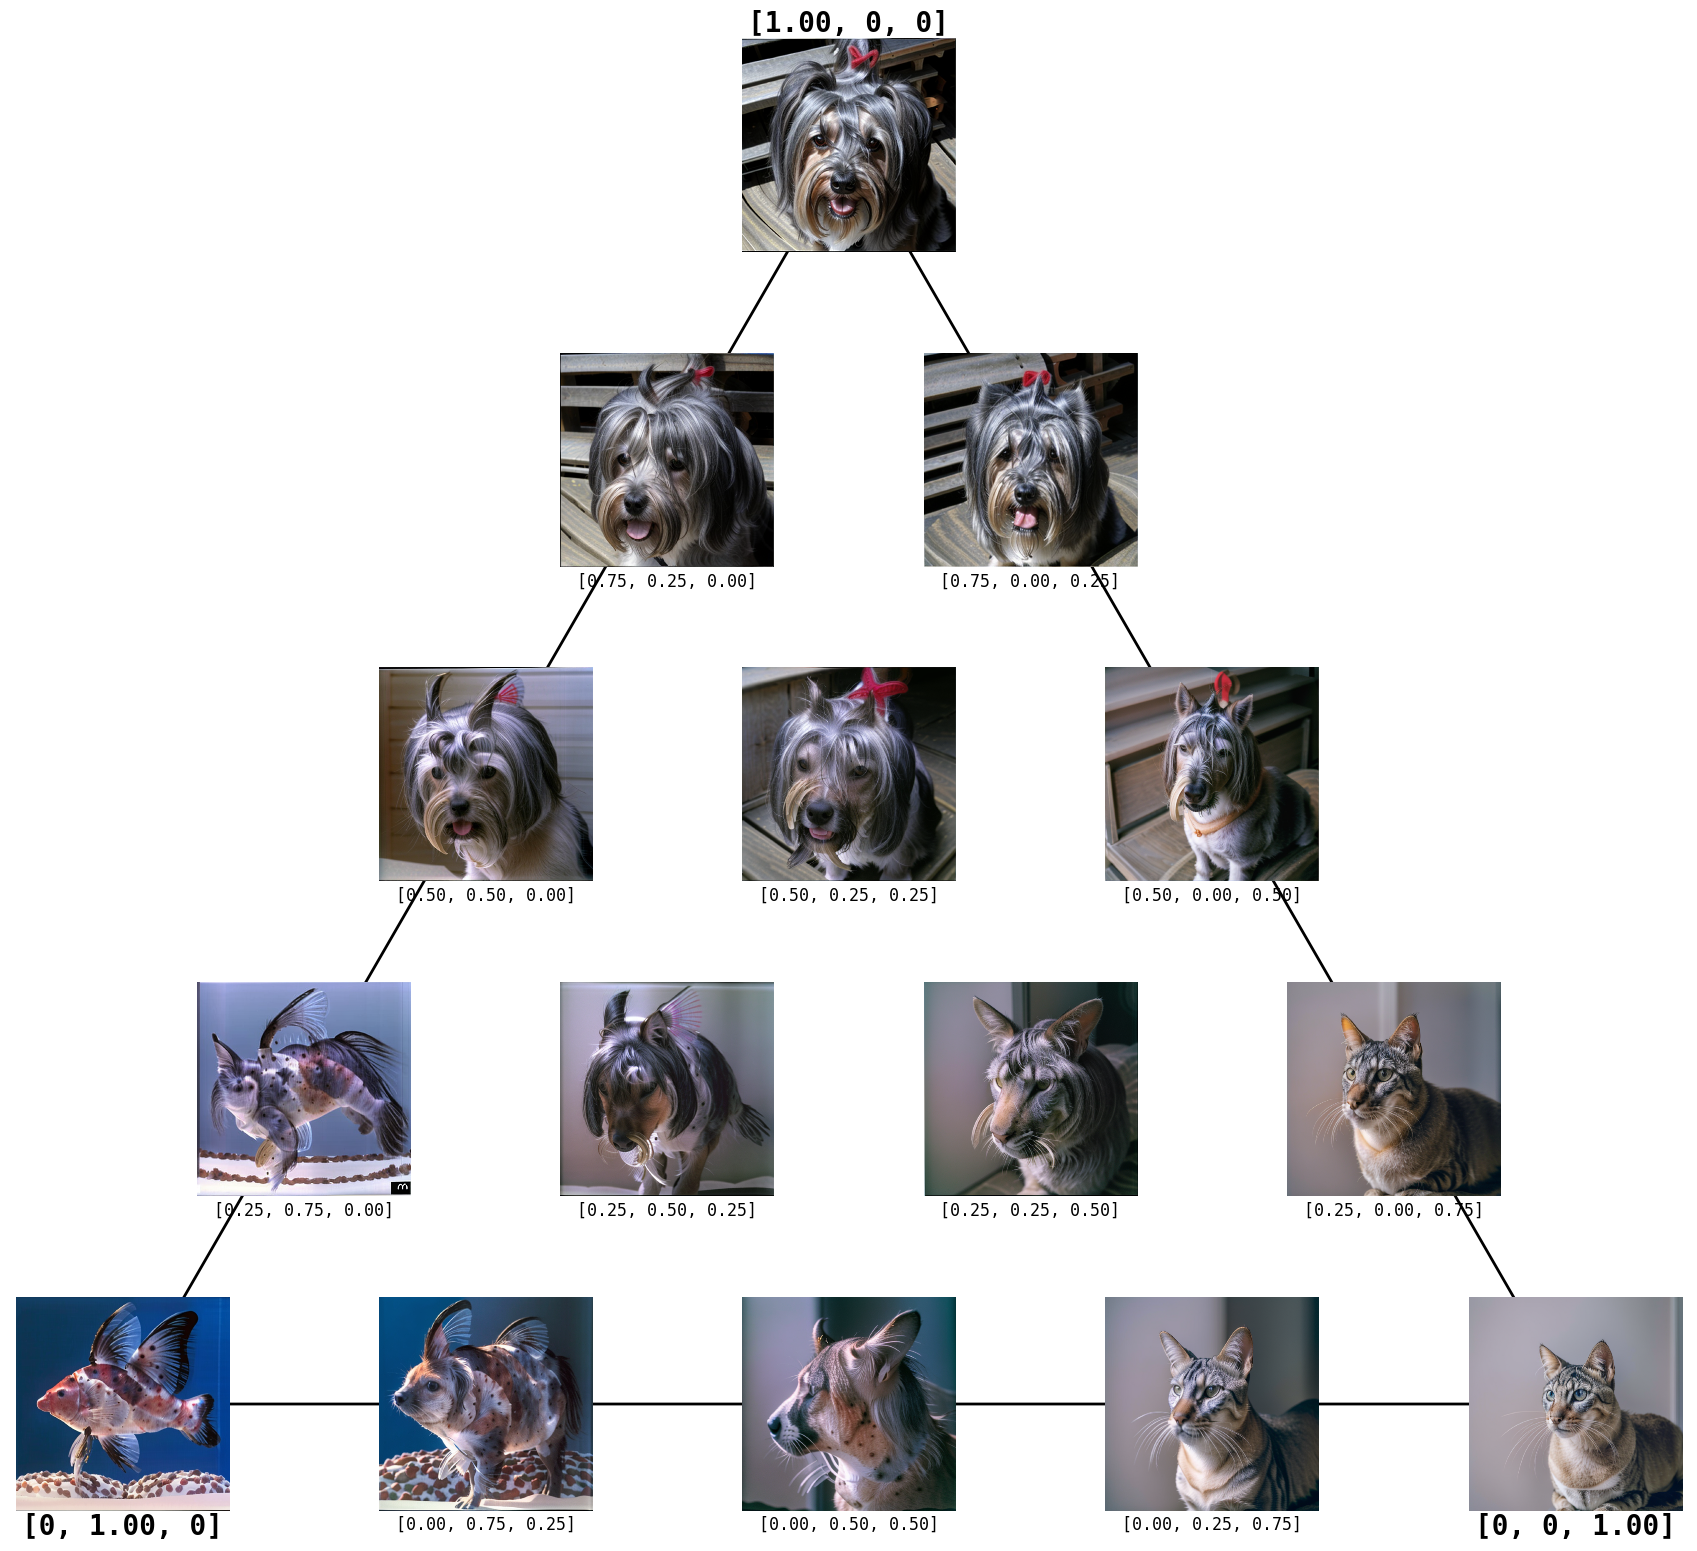

In [5]:
# Visualize interpolations on a barycentric triangle
from matplotlib.patches import Polygon

if len(image_list) != 3:
    raise ValueError("Triangle visualization requires exactly three source images.")
if len(interpolated_images) < 3:
    raise ValueError("Need at least the three corner interpolations to plot the triangle.")

def _barycentric_to_cartesian(weights: np.ndarray, vertices: np.ndarray) -> np.ndarray:
    weights = np.asarray(weights, dtype=np.float32)
    total = weights.sum()
    if total == 0:
        return vertices.mean(axis=0)
    normalized = weights / total
    return (normalized[:, None] * vertices).sum(axis=0)

def _add_image(ax, pil_image: Image.Image, position, zoom=0.18):
    arr = np.array(pil_image.convert("RGB"))
    img_artist = OffsetImage(arr, zoom=zoom)
    annotation = AnnotationBbox(img_artist, position, frameon=False)
    ax.add_artist(annotation)

sqrt3_over_2 = np.sqrt(3) / 2
scale_factor = 6.0
triangle_vertices = np.array([
    [0.5 * scale_factor, sqrt3_over_2 * scale_factor],
    [0.0, 0.0],
    [1.0 * scale_factor, 0.0],
])

fig, ax = plt.subplots(figsize=(20, 20))
triangle = Polygon(triangle_vertices, closed=True, linewidth=2.0, fill=False)
ax.add_patch(triangle)
ax.set_xlim(-0.2, scale_factor + 0.2)
ax.set_ylim(-0.2, sqrt3_over_2 * scale_factor + 0.2)
ax.set_aspect('equal')
ax.axis('off')

corner_weights = weight_schedule[:3]
corner_images = interpolated_images[:3]
image_labels = [f"Image {idx + 1}" for idx in range(len(image_list))]
corner_labels = [
    f"[{corner_weight:.2f}, 0, 0]",
    f"[0, {corner_weight:.2f}, 0]",
    f"[0, 0, {corner_weight:.2f}]"
]

for idx, (weights, img, label) in enumerate(zip(corner_weights, corner_images, corner_labels)):
    position = _barycentric_to_cartesian(weights, triangle_vertices)
    _add_image(ax, img, position, zoom=0.3)
    if idx == 0:
        ax.text(position[0], position[1]+0.56, label, ha='center', va='top', fontsize=20, fontweight='bold')
    else:
        ax.text(position[0], position[1]-0.45, label, ha='center', va='top', fontsize=20, fontweight='bold')

interior_weights = weight_schedule[3:]
interior_images = interpolated_images[3:]
for weights, img in zip(interior_weights, interior_images):
    position = _barycentric_to_cartesian(weights, triangle_vertices)
    _add_image(ax, img, position, zoom=0.3)
    ax.text(
        position[0],
        position[1] - 0.5,
        f"[{weights[0]:.2f}, {weights[1]:.2f}, {weights[2]:.2f}]",
        ha='center',
        va='center',
        fontsize=12
    )

#ax.set_title("Interpolated Images in Weight Simplex", fontsize=14)
plt.show()

## Visualization Utilities

Helper to arrange the source and generated images in a single grid.

In [6]:
def create_image_grid(images, rows, cols):
    """
    Create a grid layout of images.
    
    Args:
        images: List of PIL Images
        rows: Number of rows in the grid
        cols: Number of columns in the grid
    
    Returns:
        PIL.Image: Grid image
    """
    assert len(images) == rows * cols, f"Expected {rows*cols} images, got {len(images)}"

    # Get dimensions from first image
    width, height = images[0].size
    
    # Create empty grid canvas
    grid = Image.new('RGB', size=(cols * width, rows * height))
    
    # Paste each image into the grid
    for i, img in enumerate(images):
        x_pos = (i % cols) * width
        y_pos = (i // cols) * height
        grid.paste(img, box=(x_pos, y_pos))
    
    return grid

## Display Results

Show all source images followed by the generated blends.

In [7]:
# # Combine original images with interpolated results
# all_images = image_list + interpolated_images

# # Resize images for consistent display
# display_size = (256, 256)
# resized_images = [img.resize(display_size, Image.Resampling.LANCZOS) for img in all_images]

# # Build a single-row grid
# rows = 1
# cols = len(resized_images)

# print(f"Creating grid with {len(all_images)} images (rows={rows}, cols={cols})...")
# result_grid = create_image_grid(resized_images, rows, cols)

# print("\nInterpolation Results:")
# display(result_grid)